## Olof Sporn - Network Science Exploration

In [1]:
import os
import importlib
import numpy as np, pandas as pd, networkx as nx
import Project1.A3.desikan_killiany_atlas as dkatlas
import Project1.A3.utils_a3 as utils
# import Project1.A3.watts_in_adni as nwm
from collections import defaultdict
import Project1.A3.utils_a1_a3 as utils_a1
# import Project1.A3.gudhi_persistence_a3 as gp_a1
import Project1.A1.network_science as nc
import matplotlib.pyplot as plt
import lifelines
from sklearn.decomposition import PCA
import community as community_louvain
import warnings
PATH = os.getcwd()
BASE_DIR = utils.BASE_DIR
print(f"utils base directory: {BASE_DIR}")

utils base directory: C:\Users\sranasin\PycharmProjects\NetworkModels


In [13]:
# reload all
importlib.reload(utils); # importlib.reload(nwm); importlib.reload(gp_a1)
importlib.reload(nc)
importlib.reload(utils_a1); importlib.reload(dkatlas)

<module 'Project1.A3.desikan_killiany_atlas' from 'C:\\Users\\sranasin\\PycharmProjects\\NetworkModels\\Project1\\A3\\desikan_killiany_atlas.py'>

In [3]:
params_temp_list = {'num_nodes': 100, 'num_neighbor_nodes': 1, 'total_random_edges': 50, 'distance_threshold': 2,
                    'weighted': True, 'ngeo_placement': 'random.choice', 'n_seeds': 1, 'node_active_threshold': 0.05,
                    'upper_weight_limit': 5, 'skew_power': 3, 'seed_cluster_distance': 10,
                    'ngeom_edges_in_persistence': False, 'max_persistence_dim': 2, 'seeding_method': 'all_combinations',
                    'threshold_sum': sum(range(83)) - 300}

In [14]:
df_raw, _ = nc.main_sims([params_temp_list])

Simulating Contagion Map for simulation: 0/1
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
k

In [16]:
df_raw

,time,state,num_active_nodes,active_nodes,H_0,H_1,H_2,realization_id,seed_nodes,num_nodes,...,skew_power,seed_cluster_distance,ngeom_edges_in_persistence,max_persistence_dim,seeding_method,threshold_sum,simulation_id,average_weight_per_edge,total_geo_edges,total_non_geo_edges
0,0,0,1,[0],0,1,2,0,"(0,)",100,...,3,10,False,2,all_combinations,3103,0,0.244861,1522,132
1,1,0,2,"[0, 2]",0,1,2,0,"(0,)",100,...,3,10,False,2,all_combinations,3103,0,0.244861,1522,132
2,2,0,6,"[0, 2, 3, 4, 7, 8]",0,1,2,0,"(0,)",100,...,3,10,False,2,all_combinations,3103,0,0.244861,1522,132
3,3,0,38,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0,1,2,0,"(0,)",100,...,3,10,False,2,all_combinations,3103,0,0.244861,1522,132
4,4,0,75,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0,1,2,0,"(0,)",100,...,3,10,False,2,all_combinations,3103,0,0.244861,1522,132
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377,2,0,10,"[65, 66, 67, 68, 69, 70, 71, 73, 81, 63]",0,1,2,81,"(81,)",100,...,3,10,False,2,all_combinations,3103,0,0.244861,1522,132
378,3,0,35,"[41, 44, 45, 46, 47, 48, 49, 50, 55, 56, 57, 5...",0,1,2,81,"(81,)",100,...,3,10,False,2,all_combinations,3103,0,0.244861,1522,132
379,4,1,75,"[0, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 1...",0,1,2,81,"(81,)",100,...,3,10,False,2,all_combinations,3103,0,0.244861,1522,132
380,5,1,83,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0,1,2,81,"(81,)",100,...,3,10,False,2,all_combinations,3103,0,0.244861,1522,132


In [17]:
df_raw['seed_nodes'] = df_raw['seed_nodes'].str[0]
df = df_raw[['realization_id', 'seed_nodes', 'time', 'state', 'num_active_nodes', 'active_nodes', 'threshold_sum', 'node_active_threshold']]
df

,realization_id,seed_nodes,time,state,num_active_nodes,active_nodes,threshold_sum,node_active_threshold
0,0,0,0,0,1,[0],3103,0.05
1,0,0,1,0,2,"[0, 2]",3103,0.05
2,0,0,2,0,6,"[0, 2, 3, 4, 7, 8]",3103,0.05
3,0,0,3,0,38,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",3103,0.05
4,0,0,4,0,75,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",3103,0.05
...,...,...,...,...,...,...,...,...
377,81,81,2,0,10,"[65, 66, 67, 68, 69, 70, 71, 73, 81, 63]",3103,0.05
378,81,81,3,0,35,"[41, 44, 45, 46, 47, 48, 49, 50, 55, 56, 57, 5...",3103,0.05
379,81,81,4,1,75,"[0, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 1...",3103,0.05
380,81,81,5,1,83,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",3103,0.05


### Network Properties (Local)

In [18]:
graph, _ = nc.simulate_contagion_map(params_temp_list)
graph.nodes(data=True)[0]

ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
ksdjfsdf
k

{'dn_position_x': 34.0419230769,
 'dn_position_y': 82.1757692308,
 'dn_position_z': 31.7769230769,
 'dn_correspondence_id': 1,
 'dn_region': 'cortical',
 'dn_fsname': 'lateralorbitofrontal',
 'dn_name': 'rh.lateralorbitofrontal',
 'dn_hemisphere': 'right',
 'region_name': 'rh_lateralorbitofrontal'}

In [19]:
list(graph.edges(data=True))[0:1]

[(0,
  1,
  {'number_of_fibers': 5.62910798122,
   'FA_mean': 0.178233936269,
   'fiber_length_std': 0.816500084943,
   'fiber_length_mean': 15.9575699282,
   'FA_std': 0.116142955546,
   'weight': np.float64(0.0),
   'type': 'geometric'})]

In [20]:
def participation_coefficient(G, partition):
    pc = {}
    total = dict(G.degree())

    for node in G.nodes():
        if total[node] == 0:
            pc[node] = 0.0
            continue

        module_sum = defaultdict(float)
        for nbr, edata in G[node].items():
            w = edata.get('weight', 1.0)
            module_sum[partition[nbr]] += w

        frac_sq_sum = 0.0
        for mw in module_sum.values():
            frac = mw / total[node]
            frac_sq_sum += frac * frac

        pc[node] = 1.0 - frac_sq_sum
    return pc

In [24]:
# Degree
degree = dict(graph.degree())

# Clustering COefficient
clustering = nx.clustering(graph, weight="weight")

# BEtweenness
# AHve to make a large distance measure to imply a stronger connection (whereas in our code larger distance imply weaker connection)
graph_temp = graph.copy()
for u, v, data in graph_temp.edges(data=True):
    data['distance'] = 1.0 / max(data.get('weight'), 1e-4)

betweenness = nx.betweenness_centrality(graph_temp, weight="distance", normalized=True)

# closeness
closeness = nx.closeness_centrality(graph_temp, distance='distance')

# Modularity
module = community_louvain.best_partition(graph_temp, weight='weight')

# Participation (Hub or not)
participation = participation_coefficient(graph_temp, module)

In [25]:
nodes = sorted(graph.nodes())

df_props = pd.DataFrame({
    "Node": nodes,
    "Degree": [degree[n] for n in nodes],
    "Clustering": [clustering[n] for n in nodes],
    "Closeness": [closeness[n] for n in nodes],
    "Betweenness": [betweenness[n] for n in nodes],
    "Module": [module[n] for n in nodes],
    "Participation": [participation[n] for n in nodes],
})


In [26]:
df_props

,Node,Degree,Clustering,Closeness,Betweenness,Module,Participation
0,0,35,0.002009,0.000630,0.000043,0,0.946939
1,1,25,0.000481,0.000630,0.000000,0,0.993600
2,2,12,0.000000,0.000088,0.000000,1,1.000000
3,3,35,0.001275,0.000630,0.000043,0,0.991837
4,4,40,0.000663,0.000630,0.000489,0,0.969375
...,...,...,...,...,...,...,...
78,78,50,0.000400,0.000630,0.005415,3,0.993200
79,79,42,0.000000,0.000091,0.000117,15,1.000000
80,80,54,0.000680,0.000630,0.092135,3,0.984568
81,81,41,0.000176,0.000630,0.000168,12,0.997620


### PRepare for Cox-PH (Not time varying)

In [27]:
def collapse_run(run):
    run = run.sort_values("time")

    # Check if event occurred
    event_rows = run[run["state"] == 1]

    if len(event_rows) > 0:
        event = 1
        first_event_row = event_rows.iloc[0]
        duration = first_event_row["time"]
        active_at_event = first_event_row["num_active_nodes"]
    else:
        event = 0
        last_row = run.iloc[-1]
        duration = last_row["time"]
        active_at_event = last_row["num_active_nodes"]

    return pd.Series({
        "duration": duration,
        "event": event,
        "active_at_event": active_at_event})


In [28]:
warnings.filterwarnings("ignore")
survival_df = (
    df
    .groupby("seed_nodes", as_index=False)
    .apply(collapse_run)
    .reset_index(drop=True)
)
survival_df

,seed_nodes,duration,event,active_at_event
0,0,5,1,83
1,1,0,0,1
2,2,0,0,1
3,3,5,1,83
4,4,5,1,83
...,...,...,...,...
78,78,0,0,1
79,79,4,1,78
80,80,4,1,76
81,81,4,1,75


In [29]:
df_cox = survival_df.merge(df_props, left_on="seed_nodes", right_on="Node", how="left")
df_cox.drop(columns=["seed_nodes", "Node"], inplace=True)
df_cox.head(10)

,duration,event,active_at_event,Degree,Clustering,Closeness,Betweenness,Module,Participation
0,5,1,83,35,0.002009,0.000630,0.000043,0,0.946939
1,0,0,1,25,0.000481,0.000630,0.000000,0,0.993600
2,0,0,1,12,0.000000,0.000088,0.000000,1,1.000000
3,5,1,83,35,0.001275,0.000630,0.000043,0,0.991837
4,5,1,83,40,0.000663,0.000630,0.000489,0,0.969375
5,5,1,83,41,0.002318,0.000630,0.000112,0,0.970256
6,5,1,83,45,0.003885,0.000630,0.052341,0,0.819753
7,5,1,83,36,0.005190,0.000630,0.000552,0,0.841821
8,5,1,83,39,0.003724,0.000630,0.013588,0,0.902696
9,5,1,83,48,0.005695,0.000630,0.054990,0,0.820747


## Run cox-PH models

In [30]:
from lifelines import CoxPHFitter
from sklearn.preprocessing import StandardScaler

cph = CoxPHFitter()
cols = [c for c in df_cox.columns if c not in ['duration', 'event', 'active_at_event']]
scaler = StandardScaler()
df_cox[cols] = scaler.fit_transform(df_cox[cols])

In [31]:
cph.fit(df_cox, duration_col = "duration", event_col="event")
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 83 total observations, 20 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 83
number of events observed = 63
   partial log-likelihood = -192.84
         time fit was run = 2026-02-23 05:38:01 UTC

---
                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                        
active_at_event -0.04      0.96      0.06           -0.15            0.07                0.86                1.07
Degree           0.25      1.28      0.19           -0.13            0.62                0.88                1.86
Clustering      -0.07      0.93      0.31           -0.67            0.52                0.51                1.69
Closeness        0.04      1.05      0.17           -0.30            0.39                0.74                1.47
Betweenness      0.17      1.18      0.17           -0.16            0.50                0.85                1.64
Module           0.39      1.48      0.20           -0.01            0.79                0.99                2.21
Participation    0.07      1.07      0.32           -0.56            0.70                0.57                2.01

                 cmp to     z    p  -log2(p)
covariate                                   
active_at_event    0.00 -0.72 0.47      1.09
Degree             0.00  1.29 0.20      2.34
Clustering         0.00 -0.24 0.81      0.31
Closeness          0.00  0.26 0.80      0.33
Betweenness        0.00  1.01 0.31      1.68
Module             0.00  1.92 0.05      4.19
Participation      0.00  0.21 0.83      0.26
---
Concordance = 0.95
Partial AIC = 399.69
log-likelihood ratio test = 16.33 on 7 df
-log2(p) of ll-ratio test = 5.49

<Axes: xlabel='log(HR) (95% CI)'>

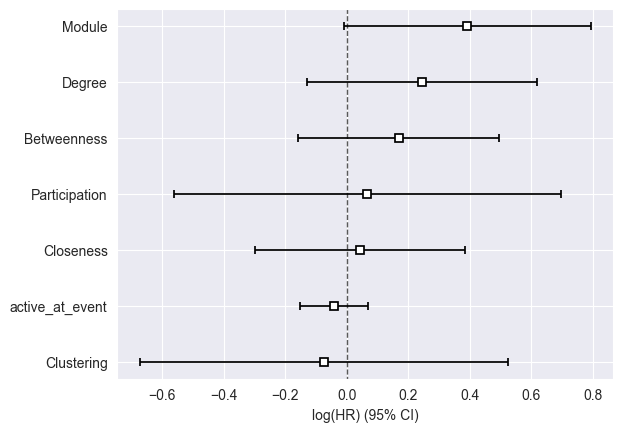

In [32]:
cph.plot()

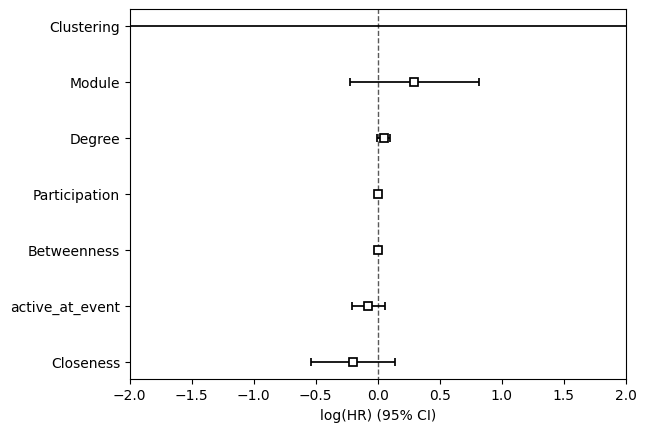

In [134]:
# # before scaling
#
# ax = cph.plot()
# ax.set_xlim(-2, 2)
# plt.show()